In [12]:
# Setup: Import required libraries
import sys

sys.path.insert(0, "/home/daniel/.local/share/src/SMT")
sys.path.insert(
    0,
    "/home/daniel/.local/share/src/SMT/scripts/dataset_generation",
)

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np

# Augraphy imports
from augraphy import *
from IPython.display import display

# Project imports for image generation
from dataset_generation.image_generation.rendering.verovio_backend import (
    VerovioRenderer,
)
from dataset_generation.image_generation.score_generator import generate
from dataset_generation.image_generation.types import GenerationConfig
from dataset_generation.image_augmentation.augraphy_augment import augraphy_augment
from dataset_generation.worker import ensure_kern_header

print("Libraries imported successfully")

Libraries imported successfully


Initializing Verovio renderer...
Renderer initialized
Loaded sample: 000000.krn (385 chars)
Generated clean image with shape: (1485, 1050, 3)


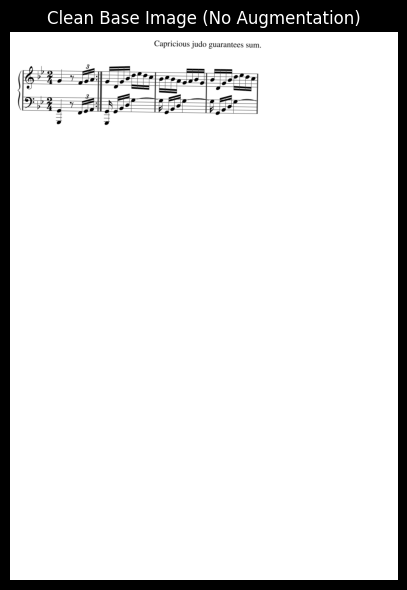

In [13]:
# Generate a clean sheet music image using the new pipeline
from pathlib import Path

print("Initializing Verovio renderer...")
renderer = VerovioRenderer()
print("Renderer initialized")

# Load a sample kern file from the normalized dataset
kern_dir = Path("/home/daniel/.local/share/src/SMT/data/interim/train/grandstaff/3_normalized")
sample_path = sorted(kern_dir.glob("*.krn"))[0]
transcription = sample_path.read_text()

# Normalized files have **kern headers stripped; Verovio requires them
transcription = ensure_kern_header(transcription)

print(f"Loaded sample: {sample_path.name} ({len(transcription)} chars)")

# Configure score generation
config = GenerationConfig(
    texturize_image=False,  # Clean base image for augmentation testing
    include_title=True,
    include_author=False,
    include_time_signature=True,
    image_width=1050,
)

# Generate the score image
result = generate(transcription, renderer, config)
assert result is not None, "Generation failed (multi-page overflow)"

clean_image = result.image
print(f"Generated clean image with shape: {clean_image.shape}")

# Display the clean image
plt.figure(figsize=(14, 6))
plt.imshow(clean_image)
plt.axis("off")
plt.title("Clean Base Image (No Augmentation)")
plt.tight_layout()
plt.show()

In [29]:
def create_pipeline(noise_intensity, line_concentration):
    """Create an augraphy pipeline with adjustable DirtyDrum parameters."""
    ink_phase = []
    paper_phase = []
    post_phase = [
            DirtyDrum(
                    line_width_range=(6, 6),
                    line_concentration=0.08,
                    direction=0,
                    noise_intensity=0.35,
                    ksize=(3, 3),
                    sigmaX=0,
                )
    ]
    pipeline = AugraphyPipeline(
        ink_phase=ink_phase, paper_phase=paper_phase, post_phase=post_phase
    )
    return pipeline

In [30]:
# Interactive sliders and display

# Output widget for displaying the image
output = widgets.Output()


def apply_and_display(noise_intensity, line_concentration, seed_value):
    """Apply augmentation with given parameters and display result."""
    with output:
        output.clear_output(wait=True)

        try:
            # Set random seed for deterministic augmentation
            np.random.seed(seed_value)

            # Create augmentation pipeline
            pipeline = create_pipeline(noise_intensity, line_concentration)

            # Apply augmentation
            augmented = pipeline.augment(clean_image.copy())["output"]

            # Display result
            fig, ax = plt.subplots(figsize=(14, 5))
            ax.imshow(augmented)
            ax.axis("off")
            ax.set_title(
                f"DirtyDrum (noise_intensity={noise_intensity:.3f}, "
                f"line_concentration={line_concentration:.3f}, seed={seed_value})",
                fontsize=12,
            )
            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"Error applying augmentation: {e}")
            import traceback

            traceback.print_exc()


# Create sliders
slider_noise = widgets.FloatSlider(
    value=0.35,
    min=0.0,
    max=1.0,
    step=0.01,
    description="noise_intensity:",
    continuous_update=False,
)

slider_concentration = widgets.FloatSlider(
    value=0.08,
    min=0.0,
    max=0.5,
    step=0.01,
    description="line_conc:",
    continuous_update=False,
)

seed_slider = widgets.IntSlider(
    value=42, min=0, max=1000, step=1, description="Seed:", continuous_update=False
)

# Create interactive widget
interactive_widget = widgets.interactive(
    apply_and_display,
    noise_intensity=slider_noise,
    line_concentration=slider_concentration,
    seed_value=seed_slider,
)

display(interactive_widget, output)

interactive(children=(FloatSlider(value=0.35, continuous_update=False, description='noise_intensity:', max=1.0…

Output()

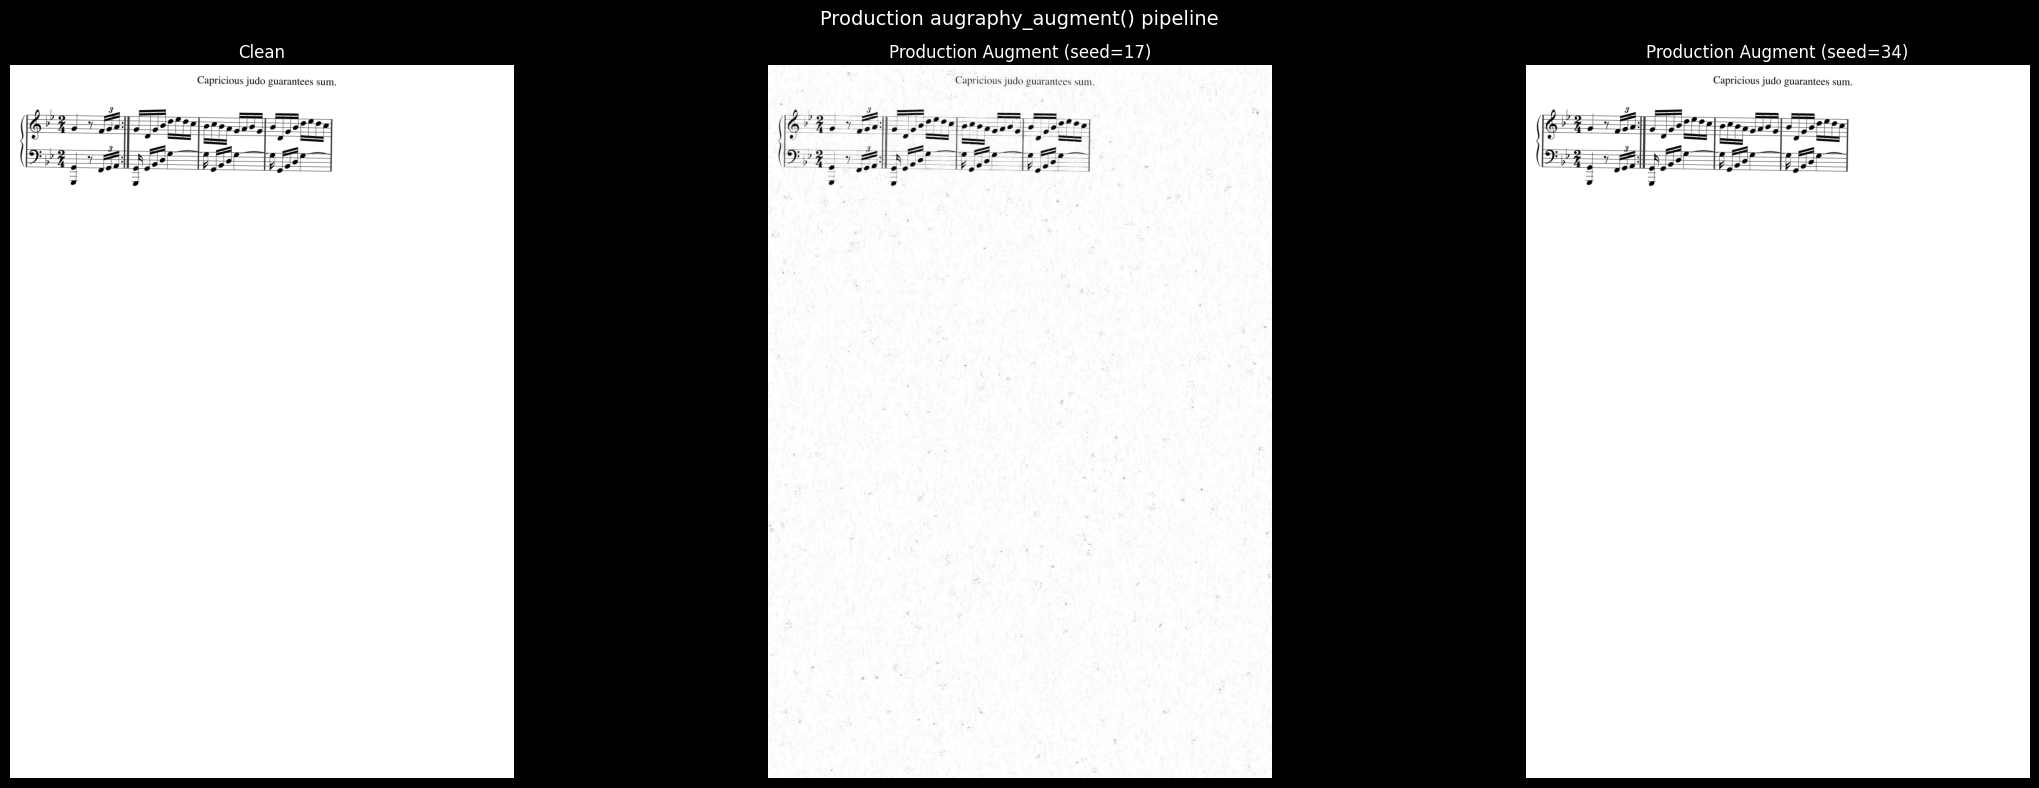

In [31]:
# Compare: production augraphy pipeline vs clean image

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Clean
axes[0].imshow(clean_image)
axes[0].set_title("Clean")
axes[0].axis("off")

# Production augmentation (two different samples)
for i, ax in enumerate(axes[1:], 1):
    np.random.seed(i * 17)
    augmented = augraphy_augment(clean_image.copy())
    ax.imshow(augmented)
    ax.set_title(f"Production Augment (seed={i * 17})")
    ax.axis("off")

plt.suptitle("Production augraphy_augment() pipeline", fontsize=14)
plt.tight_layout()
plt.show()